# Случайные графы и алгоритм Каргера

Три части: вероятность успеха алгоритма Каргера для минимального разреза, хроматическое и цикломатическое число $G(n,p)$, порог связности и диаметр $G(n,p)$. Теоремы — по книге А. М. Райгородского «Модели случайных графов».

In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({"figure.dpi": 120, "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12})

## Вспомогательные функции

In [2]:
def karger_min_cut(graph):
  """Один запуск алгоритма Каргера. Возвращает размер найденного разреза."""
  nodes = list(graph.nodes())
  edges = list(graph.edges())

  parent = {v: v for v in nodes}
  rank = {v: 0 for v in nodes}
  count = [len(nodes)]

  def find(x):
      while parent[x] != x:
          parent[x] = parent[parent[x]]
          x = parent[x]
      return x

  def union(x, y):
      rx, ry = find(x), find(y)
      if rx == ry:
          return
      if rank[rx] < rank[ry]:
          rx, ry = ry, rx
      parent[ry] = rx
      if rank[rx] == rank[ry]:
          rank[rx] += 1
      count[0] -= 1

  shuffled = edges[:]
  random.shuffle(shuffled)

  for u, v in shuffled:
      if count[0] <= 2:
          break
      if find(u) != find(v):
          union(u, v)

  return sum(1 for u, v in edges if find(u) != find(v))


def exact_min_cut(G):
  """Точный минимальный разрез — алгоритм Штёра — Вагнера"""
  if not nx.is_connected(G):
      return 0
  val, _ = nx.stoer_wagner(G)
  return val


def cyclomatic_number(G):
  return G.number_of_edges() - G.number_of_nodes() + nx.number_connected_components(G)


def greedy_chromatic(G):
  col = nx.coloring.greedy_color(G, strategy="largest_first")
  return max(col.values()) + 1 if col else 0


def theoretical_chromatic(n, p):
  """Формула Боллобаша: χ ~ n·ln(1/(1-p)) / (2·ln(n))."""
  if p <= 0 or p >= 1 or n <= 1:
      return 1
  return n * math.log(1 / (1 - p)) / (2 * math.log(n))


def make_dumbbell(k):
  """Два K_k соединённых одним мостом. λ = 1."""
  G = nx.Graph()
  for i in range(k):
      for j in range(i+1, k):
          G.add_edge(i, j)
          G.add_edge(k+i, k+j)
  G.add_edge(k-1, k)   # мост
  return G

## Часть 1. Алгоритм Каргера на различных графах

Нижняя оценка вероятности успеха одного запуска:

$$P(\text{успех}) \ge \frac{2}{n(n-1)}$$

При $T$ независимых запусках:

$$P(\text{ошибка за } T \text{ запусков}) \le \left(1 - \frac{2}{n(n-1)}\right)^T$$

Для гарантии $P(\text{ошибка}) \le 1/n$ достаточно $T = \binom{n}{2} \ln n$ запусков.

Точный минимальный разрез $\lambda$ считается алгоритмом Штёра — Вагнера (`nx.stoer_wagner`), запуск Каргера успешен, если нашёл разрез размера $\lambda$.

### Эксперимент 1. Демонстрация на конкретном графе

Граф G_demo: 6 вершин, 9 рёбер, шестиугольный цикл с тремя хордами. 1000 запусков.

Точный разрез (Штёр — Вагнер): 3

Эксперимент (1000 запусков):
  Эмпирическая P(успех)        = 0.6490
  Нижняя теоретич. граница     = 0.0667
  Соотношение эмпир/теор       = 9.74x


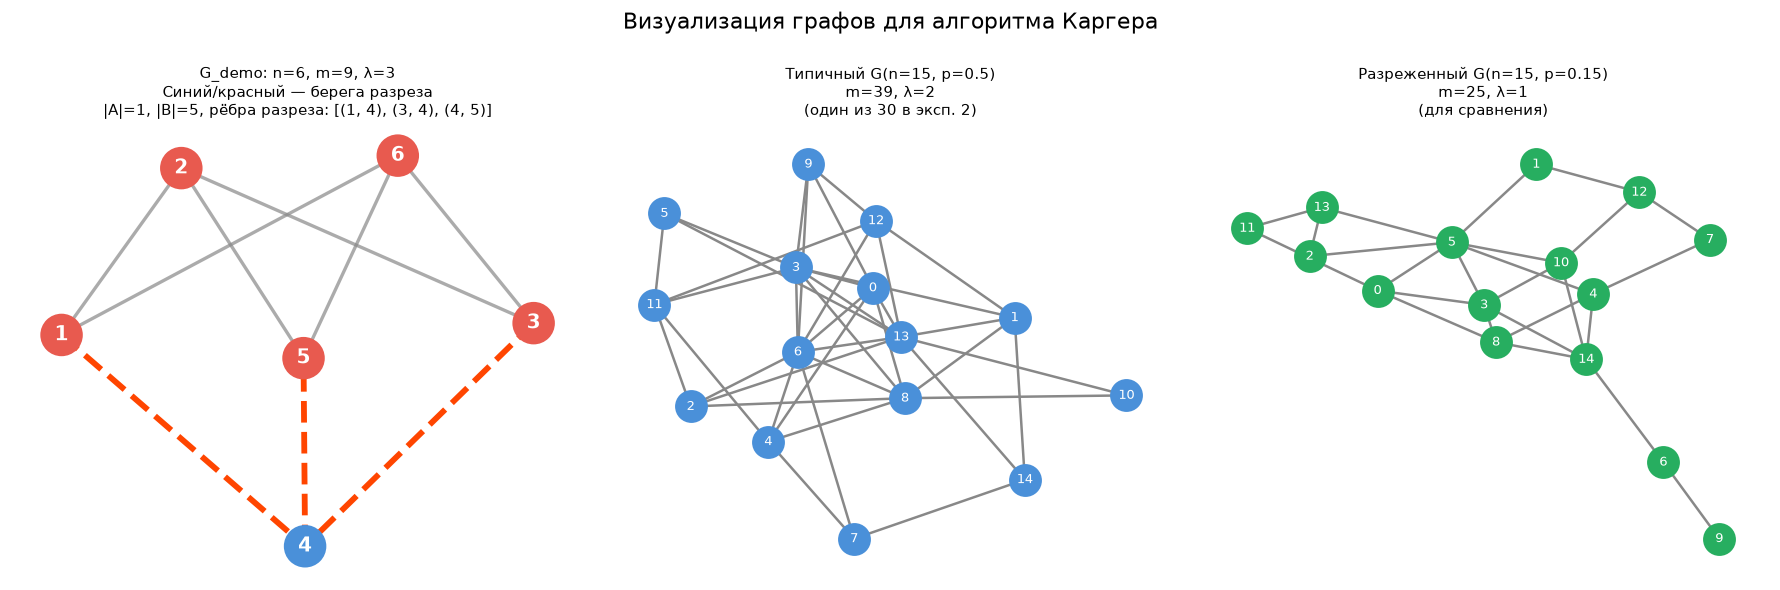

In [3]:
G_demo = nx.Graph()
G_demo.add_edges_from([(1,2),(2,3),(3,4),(4,5),(5,6),(6,1),(2,5),(3,6),(1,4)])

true_cut = exact_min_cut(G_demo)
n_demo = G_demo.number_of_nodes()
theor_prob = 2 / (n_demo * (n_demo - 1))

N_trials = 1000
results_demo = [karger_min_cut(G_demo) for _ in range(N_trials)]
emp_rate = sum(1 for r in results_demo if r == true_cut) / N_trials

print(f"Точный разрез (Штёр — Вагнер): {true_cut}")
print(f"\nЭксперимент ({N_trials} запусков):")
print(f"  Эмпирическая P(успех)        = {emp_rate:.4f}")
print(f"  Нижняя теоретич. граница     = {theor_prob:.4f}")
print(f"  Соотношение эмпир/теор       = {emp_rate/theor_prob:.2f}x")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cut_val, partition = nx.stoer_wagner(G_demo)
side_A = list(partition[0])
side_B = list(partition[1])
cut_edges = [(u,v) for u,v in G_demo.edges() if (u in side_A and v in side_B) or (u in side_B and v in side_A)]
normal_edges = [(u,v) for u,v in G_demo.edges() if (u,v) not in cut_edges]
pos = nx.spring_layout(G_demo, seed=7)
color_map = ["#4A90D9" if v in side_A else "#E85A4F" for v in G_demo.nodes()]

ax = axes[0]
nx.draw_networkx_nodes(G_demo, pos, ax=ax, node_color=color_map, node_size=600)
nx.draw_networkx_labels(G_demo, pos, ax=ax, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G_demo, pos, edgelist=normal_edges, ax=ax, edge_color="#888", width=2, alpha=0.7)
nx.draw_networkx_edges(G_demo, pos, edgelist=cut_edges, ax=ax, edge_color="#FF4500", width=3.5, style="dashed")
ax.set_title(f"G_demo: n=6, m=9, λ={cut_val}\n"
            f"Синий/красный — берега разреза\n"
            f"|A|={len(side_A)}, |B|={len(side_B)}, рёбра разреза: {cut_edges}", fontsize=9)
ax.axis("off")

# Типичный плотный G(15, 0.5)
for st in range(200):
  G_s = nx.erdos_renyi_graph(15, 0.5, seed=st)
  if nx.is_connected(G_s):
      break
tc2 = exact_min_cut(G_s)
ax = axes[1]
nx.draw_networkx(G_s, nx.spring_layout(G_s, seed=42), ax=ax, node_color="#4A90D9", node_size=350, font_color="white", font_size=8, edge_color="#888", width=1.5)
ax.set_title(f"Типичный G(n=15, p=0.5)\nm={G_s.number_of_edges()}, λ={tc2}\n(один из 30 в эксп. 2)", fontsize=9)
ax.axis("off")

# Разреженный G(15, 0.15) для сравнения
for st in range(200):
  G_sp = nx.erdos_renyi_graph(15, 0.15, seed=st)
  if nx.is_connected(G_sp):
      break
tc3 = exact_min_cut(G_sp)
ax = axes[2]
nx.draw_networkx(G_sp, nx.spring_layout(G_sp, seed=42), ax=ax, node_color="#27AE60", node_size=350, font_color="white", font_size=8, edge_color="#888", width=1.5)
ax.set_title(f"Разреженный G(n=15, p=0.15)\nm={G_sp.number_of_edges()}, λ={tc3}\n(для сравнения)", fontsize=9)
ax.axis("off")

plt.suptitle("Визуализация графов для алгоритма Каргера", fontsize=13)
plt.tight_layout()
plt.show()

### Эксперимент 2. P(успех) как функция от n

Случайные связные $G(n, 0.5)$ для n = 5, 8, 10, 15, 20, 30. Для каждого n — 30 графов по 500 запусков Каргера, P(успех) усредняется по графам.


    n |    P_теор (нижн) |    P_эмпир |   ratio
------------------------------------------------
    5 |         0.100000 |     0.5487 |    5.49x
    8 |         0.035714 |     0.3788 |   10.61x
   10 |         0.022222 |     0.3829 |   17.23x
   15 |         0.009524 |     0.2601 |   27.31x
   20 |         0.005263 |     0.2033 |   38.63x
   30 |         0.002299 |     0.1276 |   55.51x


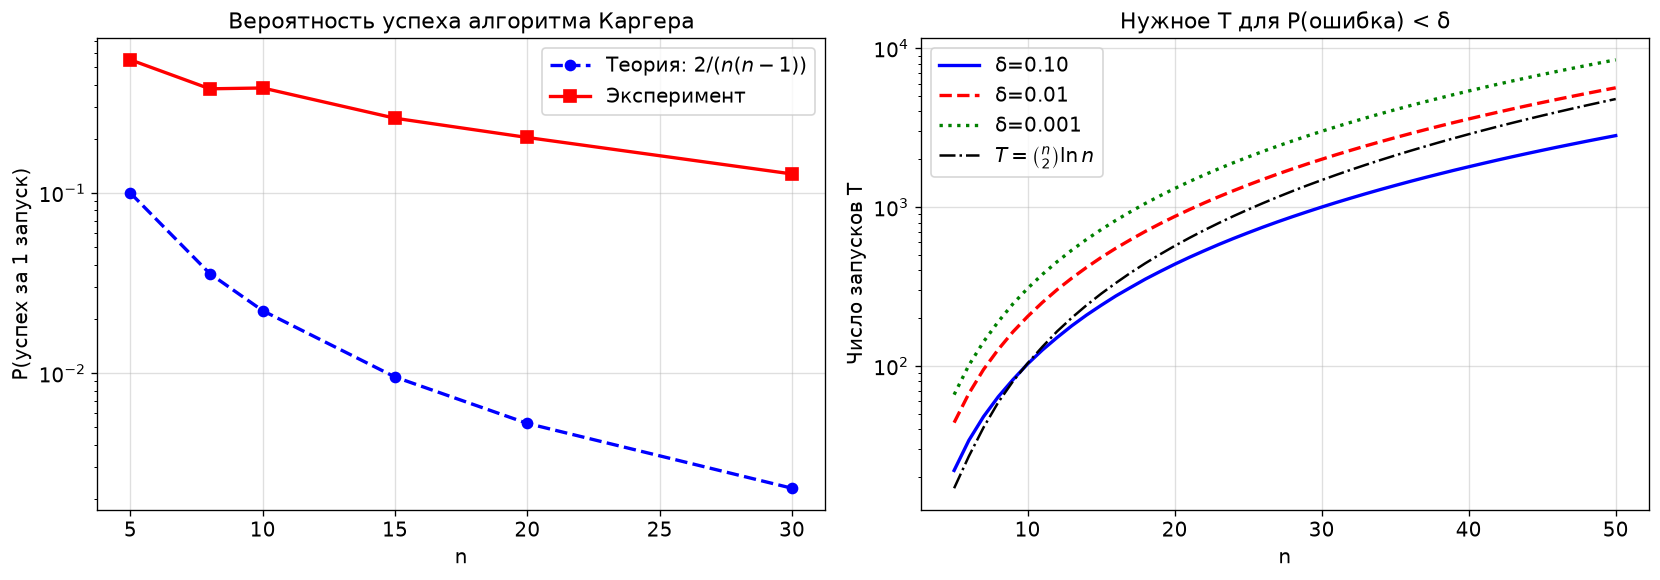

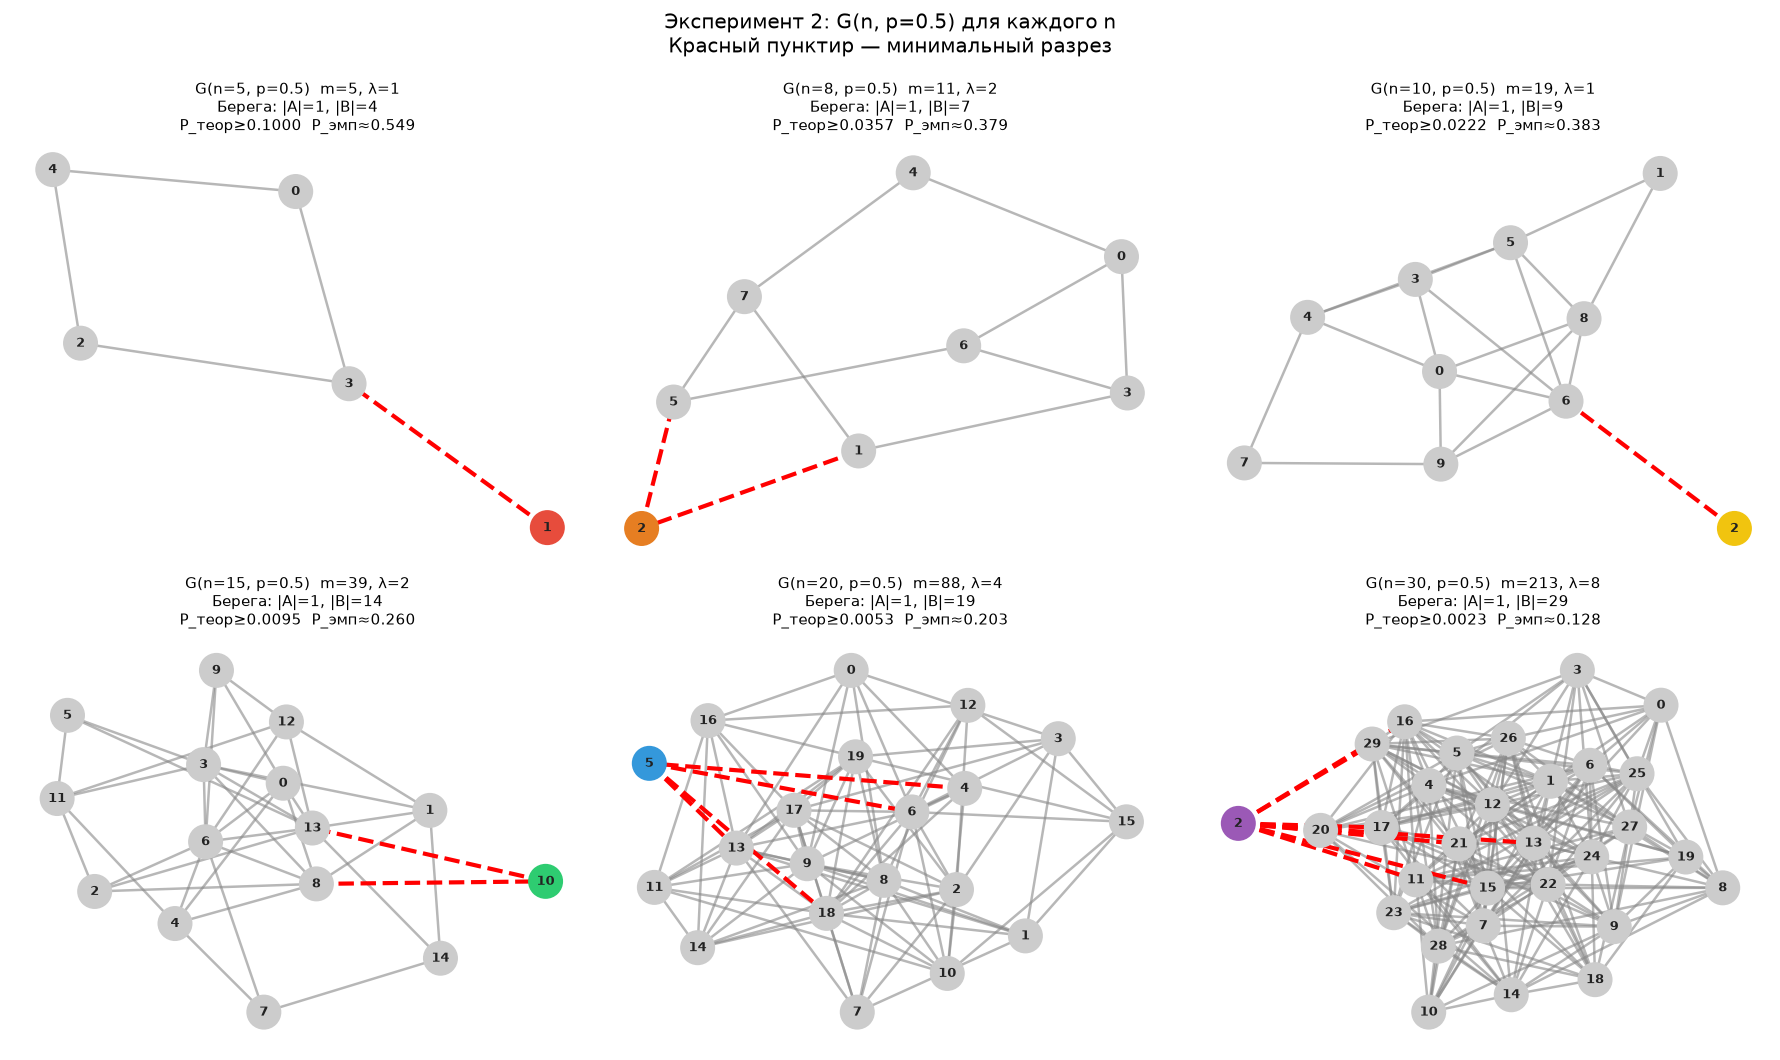

In [4]:
ns_list  = [5, 8, 10, 15, 20, 30]
N_graphs = 30
N_trials = 500

emp_probs = []
theor_probs = []

for n in ns_list:
  p_t = 2 / (n * (n - 1))
  theor_probs.append(p_t)

  rates = []
  attempts = 0
  while len(rates) < N_graphs:
      G = nx.erdos_renyi_graph(n, 0.5)
      if not nx.is_connected(G) or G.number_of_edges() < 2:
          attempts += 1
          if attempts > 200:
              break
          continue
      attempts = 0
      tc = exact_min_cut(G)
      res = [karger_min_cut(G) for _ in range(N_trials)]
      rates.append(sum(1 for r in res if r == tc) / N_trials)

  emp_probs.append(np.mean(rates))

print(f"\n{'n':>5} | {'P_теор (нижн)':>16} | {'P_эмпир':>10} | {'ratio':>7}")
print("-" * 48)
for n, pt, pe in zip(ns_list, theor_probs, emp_probs):
    print(f"{n:>5} | {pt:>16.6f} | {pe:>10.4f} | {pe/pt:>7.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ns_list, theor_probs, "b--o", label=r"Теория: $2/(n(n-1))$", lw=2)
ax.plot(ns_list, emp_probs, "r-s",  label="Эксперимент", lw=2, ms=7)
ax.set_xlabel("n")
ax.set_ylabel("P(успех за 1 запуск)")
ax.set_title("Вероятность успеха алгоритма Каргера")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.4)

ax = axes[1]
ns_fine = np.arange(5, 51)
for delta, col, ls, lbl in [
    (0.10, "blue",  "-",   "δ=0.10"),
    (0.01, "red",   "--",  "δ=0.01"),
    (0.001,"green", ":",   "δ=0.001"),
]:
    T = [math.ceil(math.log(delta) / math.log(1 - 2/(n*(n-1)))) for n in ns_fine]
    ax.plot(ns_fine, T, color=col, linestyle=ls, lw=2, label=lbl)
T_theory = [math.ceil(n*(n-1)/2 * math.log(n)) for n in ns_fine]
ax.plot(ns_fine, T_theory, "k-.", lw=1.5, label=r"$T=\binom{n}{2}\ln n$")
ax.set_xlabel("n")
ax.set_ylabel("Число запусков T")
ax.set_title("Нужное T для P(ошибка) < δ")
ax.legend()
ax.set_yscale("log")
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
colors_viz = ["#E74C3C","#E67E22","#F1C40F","#2ECC71","#3498DB","#9B59B6"]

for ax, n, col in zip(axes.flat, ns_list, colors_viz):
  for st in range(200):
      G_v = nx.erdos_renyi_graph(n, 0.5, seed=st)
      if nx.is_connected(G_v):
          break
  tc = exact_min_cut(G_v)
  _, part = nx.stoer_wagner(G_v)
  sA, sB = list(part[0]), list(part[1])
  cut_e = [(u,v) for u,v in G_v.edges()
           if (u in sA and v in sB) or (u in sB and v in sA)]
  pos_v = nx.spring_layout(G_v, seed=42)
  c_map = [col if v in sA else "#CCCCCC" for v in G_v.nodes()]
  nx.draw_networkx_nodes(G_v, pos_v, ax=ax, node_color=c_map, node_size=400)
  nx.draw_networkx_labels(G_v, pos_v, ax=ax, font_size=8, font_color="#222", font_weight="bold")
  nx.draw_networkx_edges(G_v, pos_v, ax=ax,
      edgelist=[(u,v) for u,v in G_v.edges() if (u,v) not in cut_e],
      edge_color="#888", width=1.5, alpha=0.6)
  nx.draw_networkx_edges(G_v, pos_v, ax=ax, edgelist=cut_e,
      edge_color="red", width=2.5, style="dashed")
  p_t = 2/(n*(n-1))
  ax.set_title(
      f"G(n={n}, p=0.5)  m={G_v.number_of_edges()}, λ={tc}\n"
      f"Берега: |A|={len(sA)}, |B|={len(sB)}\n"
      f"P_теор≥{p_t:.4f}  P_эмп≈{emp_probs[ns_list.index(n)]:.3f}", fontsize=9)
  ax.axis("off")

plt.suptitle("Эксперимент 2: G(n, p=0.5) для каждого n\n"
             "Красный пунктир — минимальный разрез", fontsize=12)
plt.tight_layout()
plt.show()

### Эксперимент 3. Геометрическое распределение первого успеха

Фиксированный граф $G(15, 0.5)$, seed=123. 2000 серий, в каждой запуски до первого успеха (не больше 60).

Гипотеза: номер первого успеха распределён геометрически. Нижняя граница $p_0 = 2/(n(n-1))$ задаёт форму, реальная вероятность $p_{emp}$ выше.

Тестовый граф: n=15, m=63, разрез=6


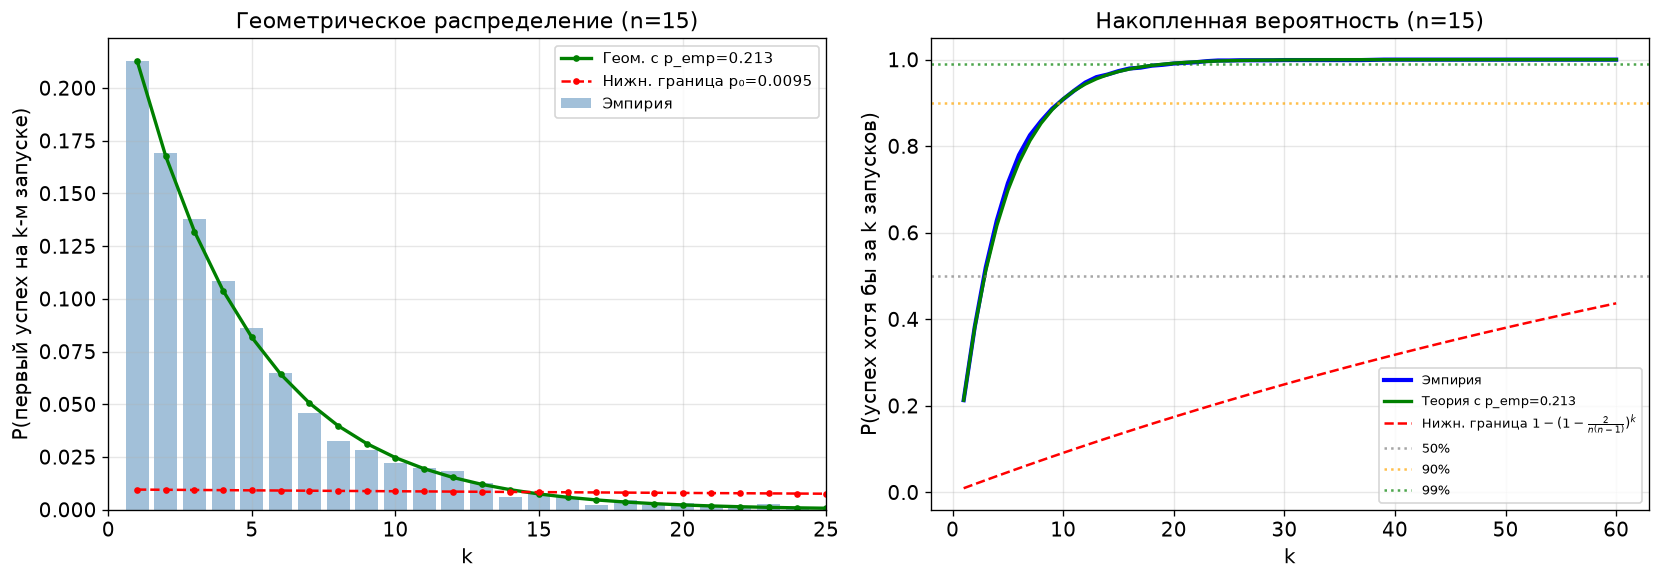


Реальная P(успех за 1 запуск): p_emp  = 0.2130
Нижняя теоретич. граница:      p0     = 0.0095
Превышение в 22.4 раз

                                 По p_emp          По p0
Медиана (50%):                          3             73
Для 90%:                               10            241
Для 99%:                               20            482


In [5]:
n_test = 15
while True:
  G_test = nx.erdos_renyi_graph(n_test, 0.5, seed=123)
  if nx.is_connected(G_test):
      break
true_cut_test = exact_min_cut(G_test)
print(f"Тестовый граф: n={n_test}, m={G_test.number_of_edges()}, разрез={true_cut_test}")

max_k = 60
N_exp = 2000
p_lower = 2 / (n_test * (n_test - 1))

first_success = []
for _ in range(N_exp):
  found = None
  for k in range(1, max_k + 1):
      if karger_min_cut(G_test) == true_cut_test:
          found = k
          break
  first_success.append(found)

p_emp = sum(1 for x in first_success if x == 1) / N_exp

ks = list(range(1, max_k + 1))
p_exact_emp = [sum(1 for x in first_success if x == k) / N_exp for k in ks]
p_exact_fit = [p_emp   * (1 - p_emp)**  (k-1) for k in ks]
p_exact_lower = [p_lower * (1 - p_lower)**(k-1) for k in ks]
p_cum_emp = [sum(1 for x in first_success if x is not None and x <= k) / N_exp for k in ks]
p_cum_fit = [1 - (1 - p_emp)**k   for k in ks]
p_cum_lower = [1 - (1 - p_lower)**k for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(ks, p_exact_emp, alpha=0.5, color="steelblue", width=0.8, label="Эмпирия")
ax.plot(ks, p_exact_fit,   "g-o", ms=3, lw=2, label=f"Геом. с p_emp={p_emp:.3f}")
ax.plot(ks, p_exact_lower, "r--o", ms=3, lw=1.5, label=f"Нижн. граница p₀={p_lower:.4f}")
ax.set_xlabel("k")
ax.set_ylabel("P(первый успех на k-м запуске)")
ax.set_title(f"Геометрическое распределение (n={n_test})")
ax.set_xlim(0, 25)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ks, p_cum_emp,   "b-",  lw=2.5, label="Эмпирия")
ax.plot(ks, p_cum_fit,   "g-",  lw=2,   label=f"Теория с p_emp={p_emp:.3f}")
ax.plot(ks, p_cum_lower, "r--", lw=1.5, label=r"Нижн. граница $1-(1-\frac{2}{n(n-1)})^k$")
for lev, col, txt in [(0.5,"gray","50%"),(0.9,"orange","90%"),(0.99,"green","99%")]:
  ax.axhline(lev, color=col, ls=":", alpha=0.7, label=txt)
ax.set_xlabel("k")
ax.set_ylabel("P(успех хотя бы за k запусков)")
ax.set_title(f"Накопленная вероятность (n={n_test})")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

med_emp = math.ceil(math.log(0.5)  / math.log(1 - p_emp))
k90_emp = math.ceil(math.log(0.1)  / math.log(1 - p_emp))
k99_emp = math.ceil(math.log(0.01) / math.log(1 - p_emp))
med_lower = math.ceil(math.log(0.5)  / math.log(1 - p_lower))
k90_lower = math.ceil(math.log(0.1)  / math.log(1 - p_lower))
k99_lower = math.ceil(math.log(0.01) / math.log(1 - p_lower))

print(f"\nРеальная P(успех за 1 запуск): p_emp  = {p_emp:.4f}")
print(f"Нижняя теоретич. граница:      p0     = {p_lower:.4f}")
print(f"Превышение в {p_emp/p_lower:.1f} раз\n")
print(f"{'':30} {'По p_emp':>10} {'По p0':>14}")
print(f"{'Медиана (50%):':30} {med_emp:>10} {med_lower:>14}")
print(f"{'Для 90%:':30} {k90_emp:>10} {k90_lower:>14}")
print(f"{'Для 99%:':30} {k99_emp:>10} {k99_lower:>14}")

### Эксперимент 4. Зависимость от p

n = 20, p от 0.1 до 0.9: как меняются $\lambda$, P(успех) и отношение к нижней границе.

n=20, нижняя теоретич. граница = 0.0053 для всех p

    p |   λ_ср |   P_эмп |   ratio
-----------------------------------
 0.10 |    1.0 |  0.7146 |   135.8x
 0.15 |    1.1 |  0.5498 |   104.5x
 0.20 |    1.3 |  0.5350 |   101.7x
 0.25 |    1.9 |  0.3447 |    65.5x
 0.30 |    2.6 |  0.3283 |    62.4x
 0.35 |    3.5 |  0.2743 |    52.1x
 0.40 |    4.3 |  0.2263 |    43.0x
 0.45 |    4.7 |  0.1885 |    35.8x
 0.50 |    5.1 |  0.2267 |    43.1x
 0.55 |    6.9 |  0.1772 |    33.7x
 0.60 |    7.2 |  0.1592 |    30.2x
 0.65 |    8.7 |  0.1495 |    28.4x
 0.70 |    9.7 |  0.1358 |    25.8x
 0.75 |   10.2 |  0.1297 |    24.6x
 0.80 |   11.9 |  0.0993 |    18.9x
 0.85 |   13.1 |  0.1172 |    22.3x
 0.90 |   14.4 |  0.1120 |    21.3x


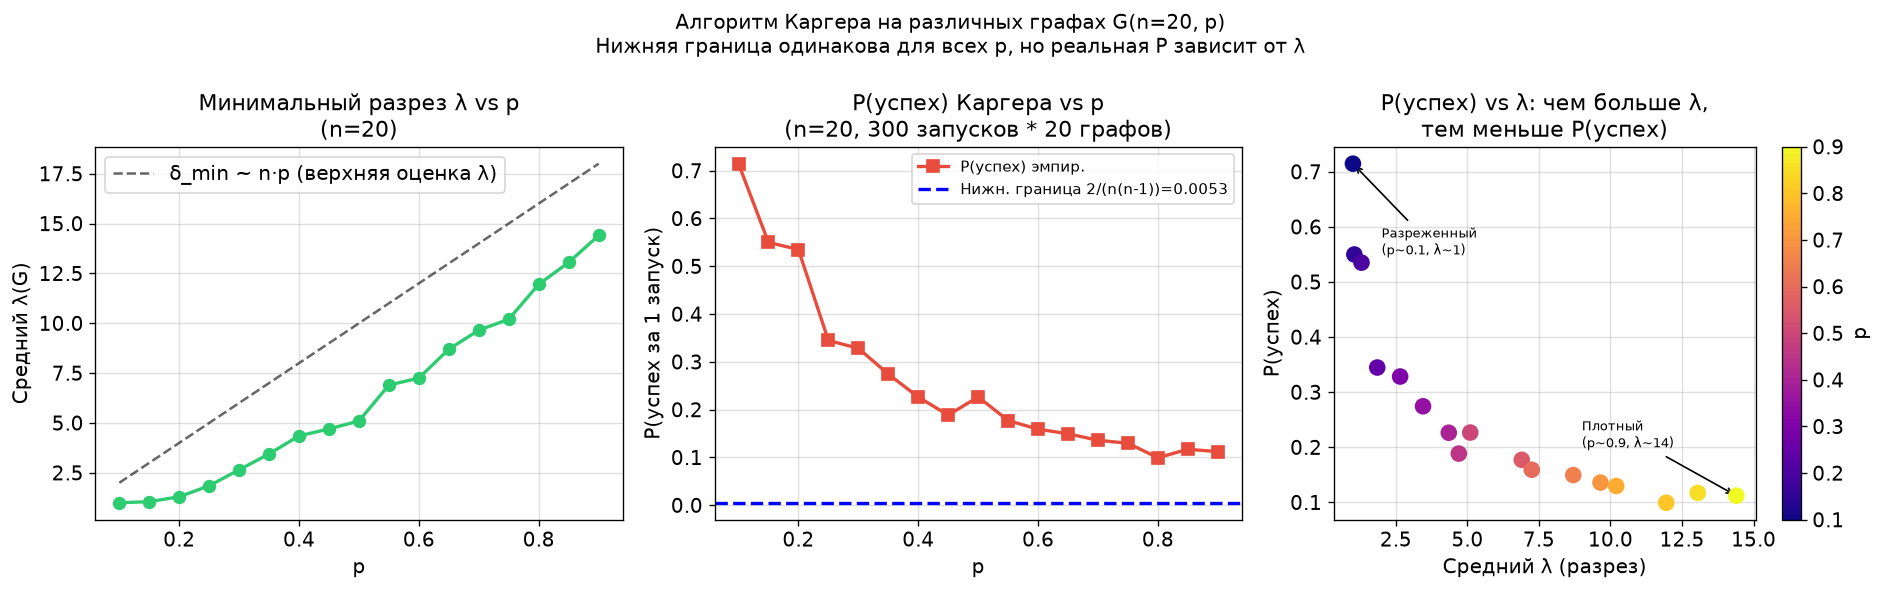


Вывод: при малом p λ~1 (разреженный граф) -> P(успех)~0.71
       при большом p λ~14 (плотный граф)  -> P(успех)~0.11
       нижняя граница одинакова = 0.0053 для всех p


In [6]:
n_fixed = 20
ps_range = np.linspace(0.1, 0.9, 17)
N_graphs_per_p = 20 # графов для усреднения
N_runs_per_g = 300 # запусков Каргера на каждый граф

emp_by_p = [] # P(успех) эмпирическая
lambda_by_p = [] # средний λ
theor_bound = 2 / (n_fixed * (n_fixed - 1)) # не зависит от p

print(f"n={n_fixed}, нижняя теоретич. граница = {theor_bound:.4f} для всех p\n")
print(f"{'p':>5} | {'λ_ср':>6} | {'P_эмп':>7} | {'ratio':>7}")
print("-" * 35)

for p in ps_range:
  rates = []
  lams  = []
  collected = 0
  tries = 0
  while collected < N_graphs_per_p and tries < 300:
    tries += 1
    G = nx.erdos_renyi_graph(n_fixed, p)
    if not nx.is_connected(G):
        continue
    lam = exact_min_cut(G)
    lams.append(lam)
    res = [karger_min_cut(G) for _ in range(N_runs_per_g)]
    rates.append(sum(r == lam for r in res) / N_runs_per_g)
    collected += 1
  emp_by_p.append(np.mean(rates))
  lambda_by_p.append(np.mean(lams))
  print(f"{p:>5.2f} | {np.mean(lams):>6.1f} | {np.mean(rates):>7.4f} | {np.mean(rates)/theor_bound:>7.1f}x")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) λ(p) средний минимальный разрез
ax = axes[0]
ax.plot(ps_range, lambda_by_p, "o-", color="#2ECC71", lw=2, ms=7)
ax.set_xlabel("p")
ax.set_ylabel("Средний λ(G)")
ax.set_title(f"Минимальный разрез λ vs p\n(n={n_fixed})")
ax.grid(alpha=0.4)

nf = np.linspace(0.1, 0.9, 200)
theor_lam = [n_fixed * p for p in nf]
ax.plot(nf, theor_lam, "k--", lw=1.5, alpha=0.6, label="δ_min ~ n·p (верхняя оценка λ)")
ax.legend()

# 2) P(успех) vs p
ax = axes[1]
ax.plot(ps_range, emp_by_p, "s-", color="#E74C3C", lw=2, ms=7, label="P(успех) эмпир.")
ax.axhline(theor_bound, color="blue", ls="--", lw=2, label=f"Нижн. граница 2/(n(n-1))={theor_bound:.4f}")
ax.set_xlabel("p")
ax.set_ylabel("P(успех за 1 запуск)")
ax.set_title(f"P(успех) Каргера vs p\n(n={n_fixed}, {N_runs_per_g} запусков * {N_graphs_per_p} графов)")
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

# 3) Scatter: P(успех) vs λ
ax = axes[2]
sc = ax.scatter(lambda_by_p, emp_by_p, c=ps_range, cmap="plasma", s=80, zorder=5)
plt.colorbar(sc, ax=ax, label="p")
ax.set_xlabel("Средний λ (разрез)")
ax.set_ylabel("P(успех)")
ax.set_title("P(успех) vs λ: чем больше λ,\nтем меньше P(успех)")
ax.grid(alpha=0.4)

ax.annotate("Разреженный\n(p~0.1, λ~1)", xy=(lambda_by_p[0], emp_by_p[0]), xytext=(2, 0.55), fontsize=8, arrowprops=dict(arrowstyle="->", color="black"))
ax.annotate("Плотный\n(p~0.9, λ~14)", xy=(lambda_by_p[-1], emp_by_p[-1]),xytext=(9, 0.2), fontsize=8, arrowprops=dict(arrowstyle="->", color="black"))

plt.suptitle("Алгоритм Каргера на различных графах G(n=20, p)\n"
             "Нижняя граница одинакова для всех p, но реальная P зависит от λ", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nВывод: при малом p λ~1 (разреженный граф) -> P(успех)~{emp_by_p[0]:.2f}")
print(f"       при большом p λ~{lambda_by_p[-1]:.0f} (плотный граф)  -> P(успех)~{emp_by_p[-1]:.2f}")
print(f"       нижняя граница одинакова = {theor_bound:.4f} для всех p")

### Эксперимент 5. Граф с заведомо малым разрезом

Dumbbell(k): два полных графа $K_k$, соединённых одним ребром-мостом, $\lambda = 1$.

In [7]:
ks = [4, 6, 8, 10, 12, 15]
N_runs_db = 500

print(f"{'Граф':>25} | {'n':>4} | {'λ':>3} | {'P_эмп':>7} | {'2/(n(n-1))':>12} | {'ratio':>7}")
print("-" * 75)

for k in ks:
  G_db = make_dumbbell(k)
  n_db = G_db.number_of_nodes()
  lam_db = exact_min_cut(G_db)
  res_db = [karger_min_cut(G_db) for _ in range(N_runs_db)]
  p_db = sum(r == lam_db for r in res_db) / N_runs_db
  bound = 2 / (n_db * (n_db - 1))
  print(f"{'Dumbbell(k='+str(k)+')':>25} | {n_db:>4} | {lam_db:>3} | {p_db:>7.4f} | {bound:>12.6f} | {p_db/bound:>7.1f}x")

# Сравниваем с G(n, 0.5) того же размера
print()
for k in [6, 10, 15]:
  n_db = 2*k
  bound = 2 / (n_db * (n_db - 1))
  rates_rand = []
  for _ in range(20):
      for _ in range(100):
          G_rand = nx.erdos_renyi_graph(n_db, 0.5)
          if nx.is_connected(G_rand): break
      lam_r = exact_min_cut(G_rand)
      res_r = [karger_min_cut(G_rand) for _ in range(N_runs_db)]
      rates_rand.append(sum(r == lam_r for r in res_r) / N_runs_db)
  p_rand = np.mean(rates_rand)
  print(f"G(n={n_db}, p=0.5): P_эмп={p_rand:.4f}, bound={bound:.6f}, ratio={p_rand/bound:.1f}x")

                     Граф |    n |   λ |   P_эмп |   2/(n(n-1)) |   ratio
---------------------------------------------------------------------------
            Dumbbell(k=4) |    8 |   1 |  0.4500 |     0.035714 |    12.6x
            Dumbbell(k=6) |   12 |   1 |  0.5720 |     0.015152 |    37.8x
            Dumbbell(k=8) |   16 |   1 |  0.5800 |     0.008333 |    69.6x
           Dumbbell(k=10) |   20 |   1 |  0.6540 |     0.005263 |   124.3x
           Dumbbell(k=12) |   24 |   1 |  0.7080 |     0.003623 |   195.4x
           Dumbbell(k=15) |   30 |   1 |  0.7460 |     0.002299 |   324.5x

G(n=12, p=0.5): P_эмп=0.3076, bound=0.015152, ratio=20.3x
G(n=20, p=0.5): P_эмп=0.2009, bound=0.005263, ratio=38.2x
G(n=30, p=0.5): P_эмп=0.1448, bound=0.002299, ratio=63.0x


## Часть 2. Хроматическое и цикломатическое число

Цикломатическое число $\mu(G) = m - n + c$, где m — рёбра, n — вершины, c — компоненты связности. Для связного $G(n,p)$ при больших n:

$$E[\mu] \approx \binom{n}{2} p - n + 1$$

Хроматическое число $\chi(G)$ — минимальное число цветов правильной раскраски вершин. Теорема Боллобаша (§2.6.1):

$$\chi(G(n,p)) \sim \frac{n \ln \frac{1}{1-p}}{2 \ln n}$$

почти наверное при $n \to \infty$.

Точное вычисление $\chi(G)$ NP-трудно, поэтому $\chi$ оценивается сверху жадной раскраской (largest_first). На $G(n,p)$ жадная раскраска асимптотически использует около $n \ln \frac{1}{1-p} / \ln n$ цветов, вдвое больше истинного $\chi$, поэтому отношение эксперимента к формуле Боллобаша стремится к 2.

Раскраска $G(12, p)$ при разных p:

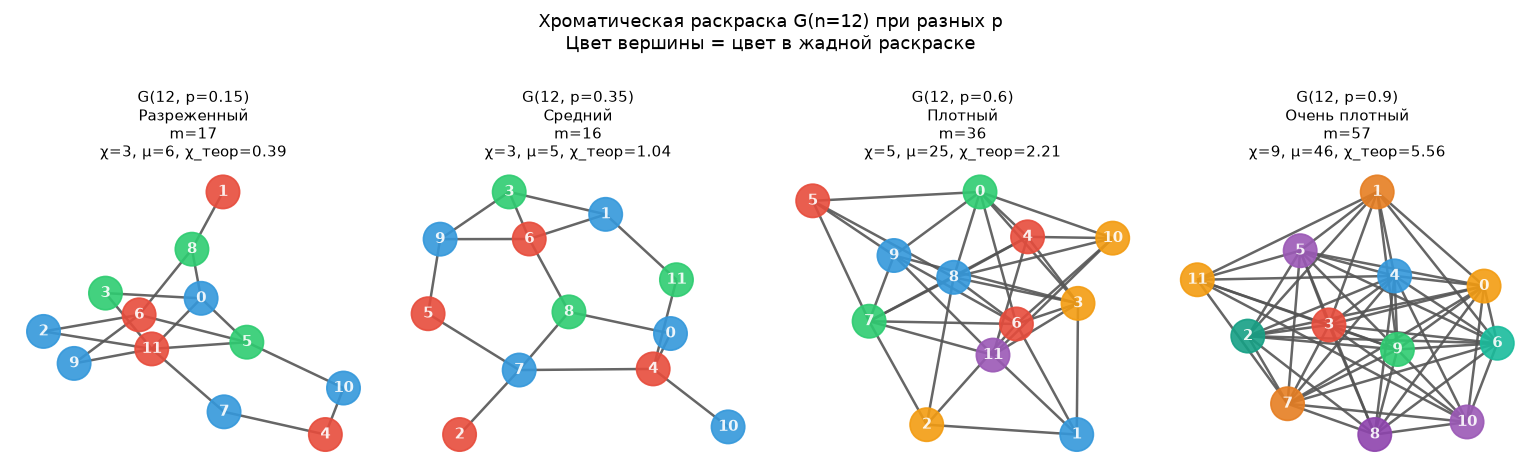

In [8]:
palette = ["#E74C3C","#3498DB","#2ECC71","#F39C12","#9B59B6","#1ABC9C","#E67E22","#16A085","#8E44AD","#C0392B","#D4AC0D","#717D7E"]

configs = [
    (nx.erdos_renyi_graph(12, 0.15, seed=1), 0.15, "G(12, p=0.15)\nРазреженный"),
    (nx.erdos_renyi_graph(12, 0.35, seed=5), 0.35, "G(12, p=0.35)\nСредний"),
    (nx.erdos_renyi_graph(12, 0.60, seed=3), 0.60, "G(12, p=0.6)\nПлотный"),
    (nx.erdos_renyi_graph(12, 0.90, seed=2), 0.90, "G(12, p=0.9)\nОчень плотный"),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, (G_c, p_val, title) in zip(axes, configs):
  for seed in range(100):
    G_c = nx.erdos_renyi_graph(12, p_val, seed=seed)
    if nx.is_connected(G_c):
        break
  chi_val  = greedy_chromatic(G_c)
  mu_val   = cyclomatic_number(G_c)
  theor_ch = theoretical_chromatic(12, p_val)
  coloring = nx.coloring.greedy_color(G_c, strategy="largest_first")
  pos_c    = nx.spring_layout(G_c, seed=42)
  node_col = [palette[coloring[v]] for v in G_c.nodes()]
  nx.draw_networkx(G_c, pos_c, ax=ax, node_color=node_col, node_size=400,font_color="white", font_size=9, font_weight="bold",edge_color="#555", width=1.5, alpha=0.9)
  ax.set_title(f"{title}\nm={G_c.number_of_edges()}\nχ={chi_val}, μ={mu_val}, χ_теор={theor_ch:.2f}", fontsize=9)
  ax.axis("off")

plt.suptitle("Хроматическая раскраска G(n=12) при разных p\n"
             "Цвет вершины = цвет в жадной раскраске", fontsize=11)
plt.tight_layout()
plt.show()

### Эксперимент 1. χ и μ как функции p

Для каждой пары (n, p) — 20 графов $G(n,p)$.

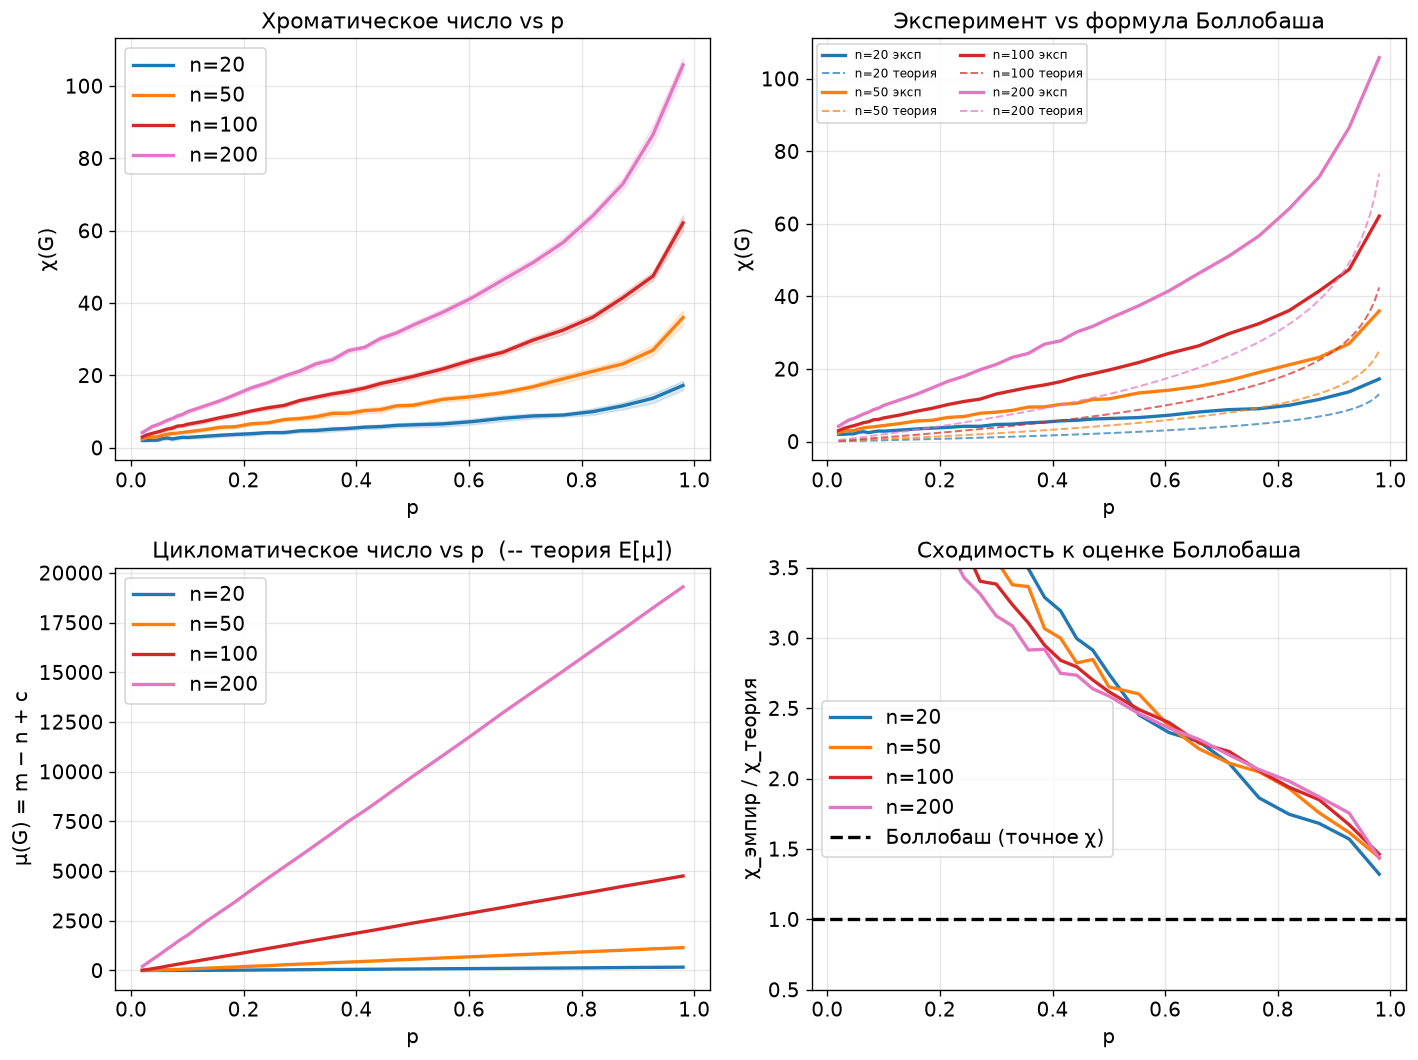

Наблюдение: χ_эмп / χ_теория > 1 при всех n.
Причина: greedy_color — верхняя оценка χ, не точное значение.
Теорема Боллобаша — про точное χ. Отношение убывает с ростом n:
  n= 20: χ_эмп/χ_теор ≈ 2.744
  n= 50: χ_эмп/χ_теор ≈ 2.653
  n=100: χ_эмп/χ_теор ≈ 2.618
  n=200: χ_эмп/χ_теор ≈ 2.587


In [9]:
ns_chr = [20, 50, 100, 200]
ps = np.concatenate([
    np.linspace(0.02, 0.1, 10),
    np.linspace(0.1,  0.5, 15),
    np.linspace(0.5,  0.98, 10),
])
N_reps = 20

results_chr = {}
for n in ns_chr:
  results_chr[n] = {}
  for p in ps:
      chi_vals = []
      mu_vals  = []
      for _ in range(N_reps):
          G = nx.erdos_renyi_graph(n, p)
          chi_vals.append(greedy_chromatic(G))
          mu_vals.append(cyclomatic_number(G))
      results_chr[n][p] = {
          "chi_mean": np.mean(chi_vals),
          "chi_std":  np.std(chi_vals),
          "mu_mean":  np.mean(mu_vals),
      }

colors = plt.cm.tab10(np.linspace(0, 0.6, len(ns_chr)))
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1) χ(p)
ax = axes[0, 0]
for n, col in zip(ns_chr, colors):
  m = [results_chr[n][p]["chi_mean"] for p in ps]
  s = [results_chr[n][p]["chi_std"]  for p in ps]
  ax.plot(ps, m, color=col, lw=2, label=f"n={n}")
  ax.fill_between(ps, np.array(m)-np.array(s), np.array(m)+np.array(s), alpha=0.15, color=col)
ax.set_xlabel("p")
ax.set_ylabel("χ(G)")
ax.set_title("Хроматическое число vs p")
ax.legend()
ax.grid(alpha=0.3)

# 2) χ vs теория Боллобаша
ax = axes[0, 1]
ps_f = np.linspace(0.02, 0.98, 120)
for n, col in zip(ns_chr, colors):
  m = [results_chr[n][p]["chi_mean"] for p in ps]
  ax.plot(ps, m, color=col, lw=2, label=f"n={n} эксп")
  ax.plot(ps_f, [theoretical_chromatic(n, p) for p in ps_f], "--", color=col, lw=1.2, alpha=0.7, label=f"n={n} теория")
ax.set_xlabel("p")
ax.set_ylabel("χ(G)")
ax.set_title("Эксперимент vs формула Боллобаша")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

# 3) μ(p)
ax = axes[1, 0]
for n, col in zip(ns_chr, colors):
  m = [results_chr[n][p]["mu_mean"] for p in ps]
  ax.plot(ps, m, color=col, lw=2, label=f"n={n}")
  ax.plot(ps_f, [max(0, n*(n-1)/2 * p - n + 1) for p in ps_f], "--", color=col, lw=1, alpha=0.6)
ax.set_xlabel("p")
ax.set_ylabel("μ(G) = m − n + c")
ax.set_title("Цикломатическое число vs p  (-- теория E[μ])")
ax.legend()
ax.grid(alpha=0.3)

# 4) χ_эмп / χ_теория — сходимость к Боллобашу
ax = axes[1, 1]
ps_keys = list(results_chr[ns_chr[0]].keys())
for n, col in zip(ns_chr, colors):
  ratio = []
  for p in ps:
      t = theoretical_chromatic(n, p)
      ratio.append(results_chr[n][p]["chi_mean"] / t if t > 0 else np.nan)
  ax.plot(ps, ratio, color=col, lw=2, label=f"n={n}")
ax.axhline(1.0, color="black", ls="--", lw=2, label="Боллобаш (точное χ)")
ax.set_xlabel("p")
ax.set_ylabel("χ_эмпир / χ_теория")
ax.set_title("Сходимость к оценке Боллобаша")
ax.set_ylim(0.5, 3.5)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Наблюдение: χ_эмп / χ_теория > 1 при всех n.")
print("Причина: greedy_color — верхняя оценка χ, не точное значение.")
print("Теорема Боллобаша — про точное χ. Отношение убывает с ростом n:")
for n in ns_chr:
  p_closest = min(ps_keys, key=lambda x: abs(x - 0.5))
  t = theoretical_chromatic(n, p_closest)
  ratio_val = results_chr[n][p_closest]["chi_mean"] / t
  print(f"  n={n:3d}: χ_эмп/χ_теор ≈ {ratio_val:.3f}")

### Эксперимент 2. χ как функция n при фиксированных p

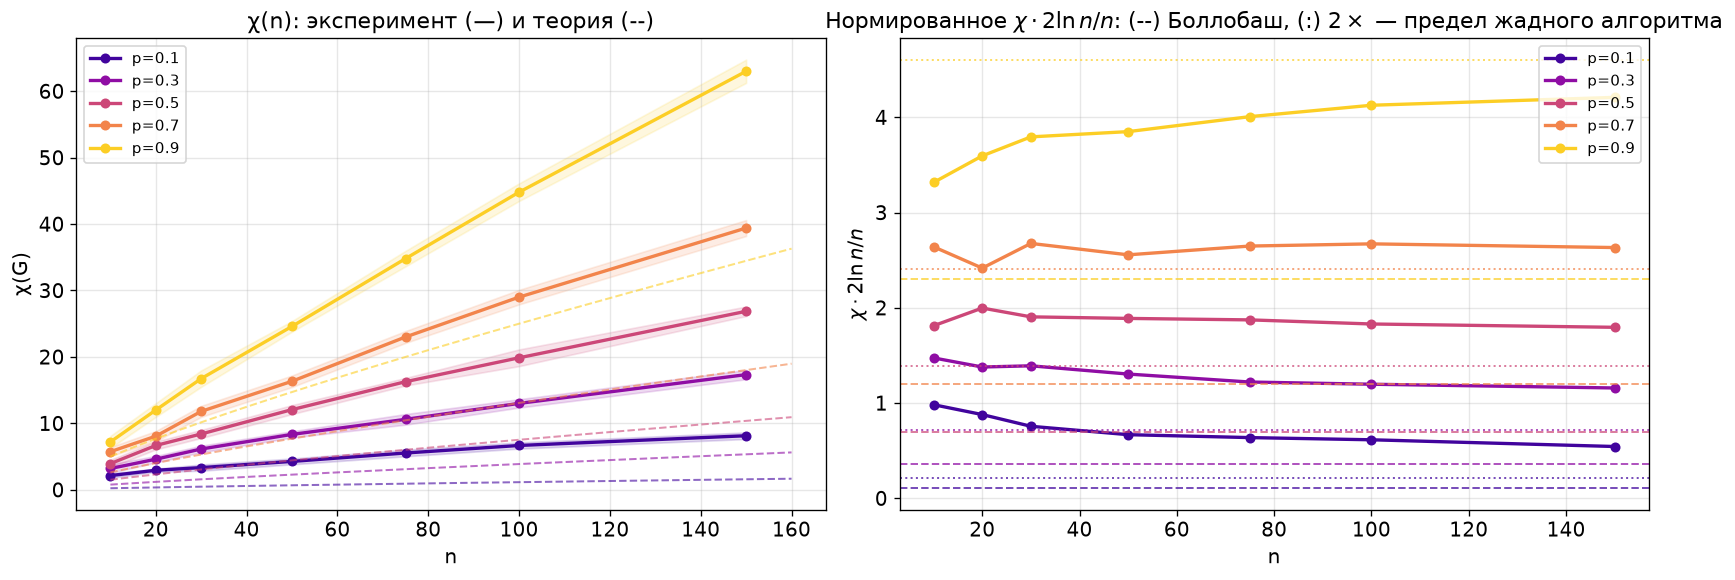

In [10]:
ps_fixed = [0.1, 0.3, 0.5, 0.7, 0.9]
ns_rng = [10, 20, 30, 50, 75, 100, 150]
N_reps2 = 15

chi_n  = {p: [] for p in ps_fixed}
chi_sd = {p: [] for p in ps_fixed}

for n in ns_rng:
  for p in ps_fixed:
      vals = [greedy_chromatic(nx.erdos_renyi_graph(n, p)) for _ in range(N_reps2)]
      chi_n[p].append(np.mean(vals))
      chi_sd[p].append(np.std(vals))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols2 = plt.cm.plasma(np.linspace(0.1, 0.9, len(ps_fixed)))

ax = axes[0]
for p, col in zip(ps_fixed, cols2):
  m = chi_n[p]
  s = chi_sd[p]
  ax.plot(ns_rng, m, "-o", color=col, lw=2, ms=5, label=f"p={p}")
  ax.fill_between(ns_rng, np.array(m)-np.array(s), np.array(m)+np.array(s), alpha=0.15, color=col)
  nf = np.linspace(10, 160, 200)
  ax.plot(nf, [theoretical_chromatic(ni, p) for ni in nf], "--", color=col, alpha=0.6, lw=1.2)
ax.set_xlabel("n")
ax.set_ylabel("χ(G)")
ax.set_title("χ(n): эксперимент (—) и теория (--)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
for p, col in zip(ps_fixed, cols2):
  norm = [chi_n[p][i] * 2 * math.log(ns_rng[i]) / ns_rng[i] for i in range(len(ns_rng))]
  ax.plot(ns_rng, norm, "-o", color=col, lw=2, ms=5, label=f"p={p}")
  ax.axhline(math.log(1/(1-p)), color=col, ls="--", alpha=0.7, lw=1.2)
  ax.axhline(2*math.log(1/(1-p)), color=col, ls=":", alpha=0.7, lw=1.2)

ax.set_xlabel("n")
ax.set_ylabel(r"$\chi \cdot 2\ln n / n$")
ax.set_title(r"Нормированное $\chi\cdot 2\ln n/n$: (--) Боллобаш, (:) $2\times$ — предел жадного алгоритма")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Эксперимент 3. Цикломатическое число в разных режимах p

- $p \ll 1/n$: $\mu \approx 0$
- $p = 1/n$: порог появления первых циклов
- $p \gg 1/n$: $\mu \approx \binom{n}{2} p - n + 1$, квадратичный рост

     n |                         p |    E[μ]_теор |     μ_эмп |   ratio
----------------------------------------------------------------------
    50 |                   p=0.5/n |         0.00 |      0.03 |     nan
   100 |                   p=0.5/n |         0.00 |      0.03 |     nan
   200 |                   p=0.5/n |         0.00 |      0.03 |     nan
   500 |                   p=0.5/n |         0.00 |      0.04 |     nan
    50 |                     p=1/n |         0.00 |      0.38 |     nan
   100 |                     p=1/n |         0.00 |      0.53 |     nan
   200 |                     p=1/n |         0.00 |      0.61 |     nan
   500 |                     p=1/n |         0.00 |      0.95 |     nan
    50 |                     p=2/n |         0.00 |      7.95 |     nan
   100 |                     p=2/n |         0.00 |     16.00 |     nan
   200 |                     p=2/n |         0.00 |     31.28 |     nan
   500 |                     p=2/n |         0.00 |     79.27 |  

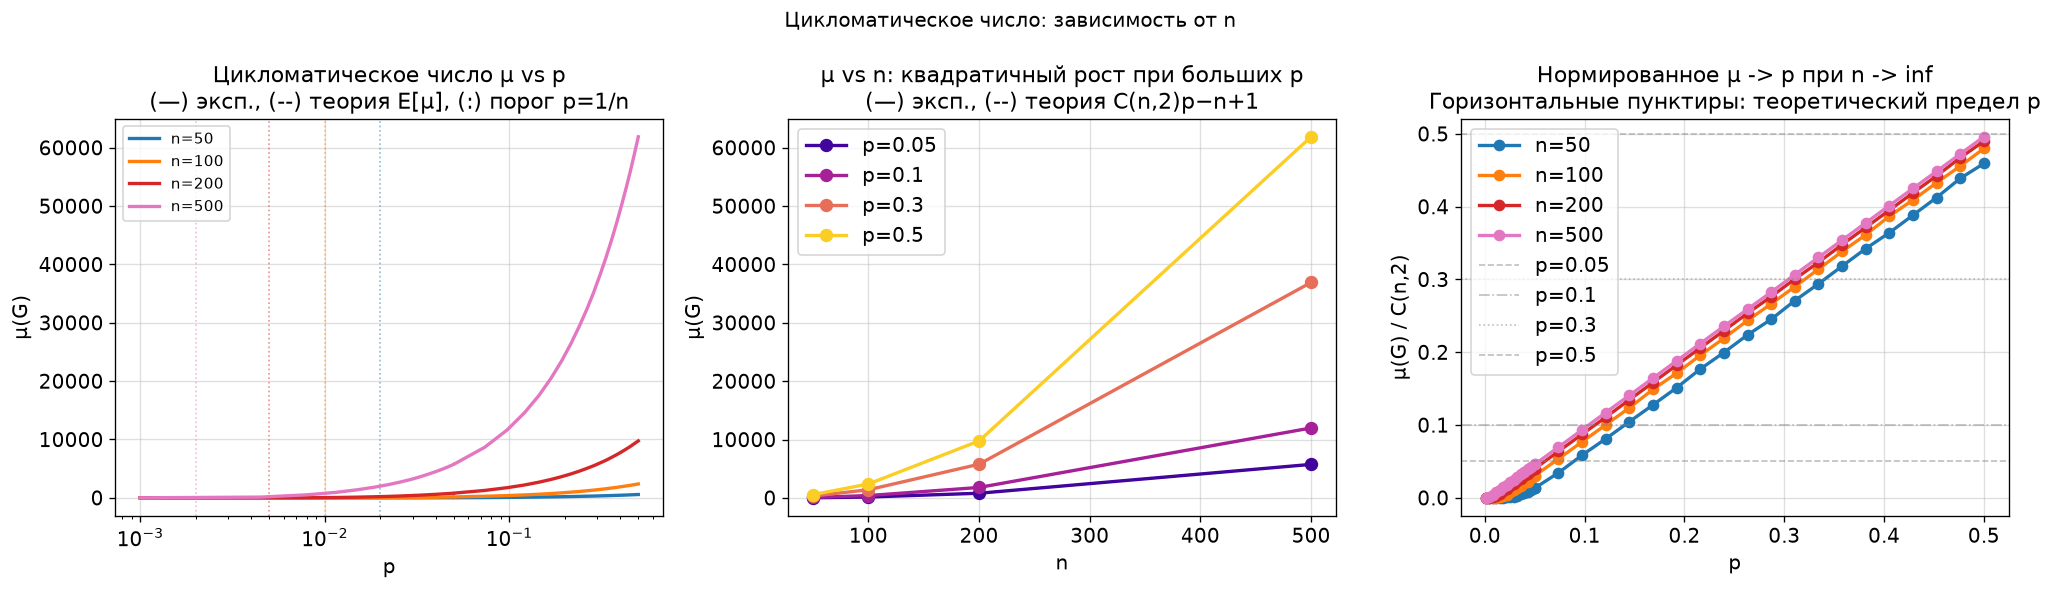

Вывод по μ:
  При p << 1/n: μ ~ 0 — циклов нет
  При p = 1/n: порог — начинают появляться первые циклы
  При p >> 1/n: μ ~ C(n,2)*p − n + 1 (квадратично растёт с n)
  μ/C(n,2) -> p — плотность 'лишних' рёбер стремится к p


In [11]:
ns_mu = [50, 100, 200, 500]
regimes = {
  "p=0.5/n": lambda n: 0.5/n,
  "p=1/n": lambda n: 1.0/n,
  "p=2/n": lambda n: 2.0/n,
  "p=ln(n)/n": lambda n: math.log(n)/n,
  "p=0.1": lambda n: 0.1,
  "p=0.5": lambda n: 0.5,
}
N_mu = 200

print(f"{'n':>6} | {'p':>25} | {'E[μ]_теор':>12} | {'μ_эмп':>9} | {'ratio':>7}")
print("-" * 70)

mu_data = {}
for regime_name, p_func in regimes.items():
  mu_data[regime_name] = {"n": ns_mu, "mu_emp": [], "mu_theor": []}
  for n in ns_mu:
      p = p_func(n)
      p = max(0.001, min(0.999, p))
      mu_vals = [cyclomatic_number(nx.erdos_renyi_graph(n, p)) for _ in range(N_mu)]
      mu_emp = np.mean(mu_vals)
      mu_theor = max(0, n*(n-1)/2 * p - n + 1)
      mu_data[regime_name]["mu_emp"].append(mu_emp)
      mu_data[regime_name]["mu_theor"].append(mu_theor)
      r = mu_emp/mu_theor if mu_theor > 0.1 else float("nan")
      print(f"{n:>6} | {regime_name:>25} | {mu_theor:>12.2f} | {mu_emp:>9.2f} | {r:>7.3f}")

# μ vs p при разных n (главный эксперимент)

ns_mu2 = [50, 100, 200, 500]
ps_mu  = np.concatenate([
  np.linspace(0.001, 0.05, 15),
  np.linspace(0.05, 0.5, 20),
])
N_mu2  = 100

mu_vs_p = {n: [] for n in ns_mu2}
mu_vs_p_theor = {n: [] for n in ns_mu2}

for n in ns_mu2:
  for p in ps_mu:
      mu_vals = [cyclomatic_number(nx.erdos_renyi_graph(n, p)) for _ in range(N_mu2)]
      mu_vs_p[n].append(np.mean(mu_vals))
      mu_vs_p_theor[n].append(max(0, n*(n-1)/2 * p - n + 1))

cols_mu = plt.cm.tab10(np.linspace(0, 0.6, len(ns_mu2)))
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1) μ vs p
ax = axes[0]
for n, col in zip(ns_mu2, cols_mu):
    ax.plot(ps_mu, mu_vs_p[n], "-", color=col, lw=2, label=f"n={n}")
    ax.plot(ps_mu, mu_vs_p_theor[n], "--", color=col, lw=1, alpha=0.6)
    ax.axvline(1/n, color=col, ls=":", lw=1, alpha=0.5)
ax.set_xlabel("p")
ax.set_ylabel("μ(G)")
ax.set_xscale("log")
ax.set_title("Цикломатическое число μ vs p\n(—) эксп., (--) теория E[μ], (:) порог p=1/n")
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

# 2) μ vs n при фиксированных p
ps_for_n = [0.05, 0.1, 0.3, 0.5]
cols_pn = plt.cm.plasma(np.linspace(0.1, 0.9, len(ps_for_n)))
ax = axes[1]
for p, col in zip(ps_for_n, cols_pn):
  mu_n = []
  mu_n_theor = []
  for n in ns_mu2:
      mu_vals = [cyclomatic_number(nx.erdos_renyi_graph(n, p)) for _ in range(N_mu2)]
      mu_n.append(np.mean(mu_vals))
      mu_n_theor.append(max(0, n*(n-1)/2 * p - n + 1))
  ax.plot(ns_mu2, mu_n, "o-", color=col, lw=2, ms=7, label=f"p={p}")
  ax.plot(ns_mu2, mu_n_theor, "--", color=col, lw=1.2, alpha=0.7)
ax.set_xlabel("n")
ax.set_ylabel("μ(G)")
ax.set_title("μ vs n: квадратичный рост при больших p\n(—) эксп., (--) теория C(n,2)p−n+1")
ax.legend()
ax.grid(alpha=0.4)

# 3) Нормировка μ/C(n,2) -> p при n -> inf
ax = axes[2]
for n, col in zip(ns_mu2, cols_mu):
  mu_norm = [mu / (n*(n-1)/2) for mu in mu_vs_p[n]]
  ax.plot(ps_mu, mu_norm, "o-", color=col, lw=2, ms=6, label=f"n={n}")

for target_p, ls in [(0.05,"--"),(0.1,"-."),(0.3,":"),(0.5,"--")]:
    ax.axhline(target_p, color="gray", ls=ls, lw=1, alpha=0.5, label=f"p={target_p}")

ax.set_xlabel("p")
ax.set_ylabel("μ(G) / C(n,2)")
ax.set_title("Нормированное μ -> p при n -> inf\nГоризонтальные пунктиры: теоретический предел p")
ax.legend()
ax.grid(alpha=0.4)

plt.suptitle("Цикломатическое число: зависимость от n", fontsize=12)
plt.tight_layout()
plt.show()

print("Вывод по μ:")
print("  При p << 1/n: μ ~ 0 — циклов нет")
print("  При p = 1/n: порог — начинают появляться первые циклы")
print("  При p >> 1/n: μ ~ C(n,2)*p − n + 1 (квадратично растёт с n)")
print("  μ/C(n,2) -> p — плотность 'лишних' рёбер стремится к p")

## Часть 3. Связность и диаметр

Теорема Эрдёша — Реньи (§2.5.1), $p = c \ln n / n$:

- $c > 1$: граф почти наверное связен
- $c < 1$: граф почти наверное несвязен

Точная асимптотика на пороге (§2.5.3), $p = (\ln n + c)/n$:

$$P(G \text{ связен}) \to e^{-e^{-c}}$$

При c = 0 предел $e^{-1} \approx 0.368$.

Диаметр: $\operatorname{diam} G(n,p) \sim \ln n / \ln(np)$ почти наверное при $n \to \infty$.

### Эксперимент 1. Пороговый переход для связности

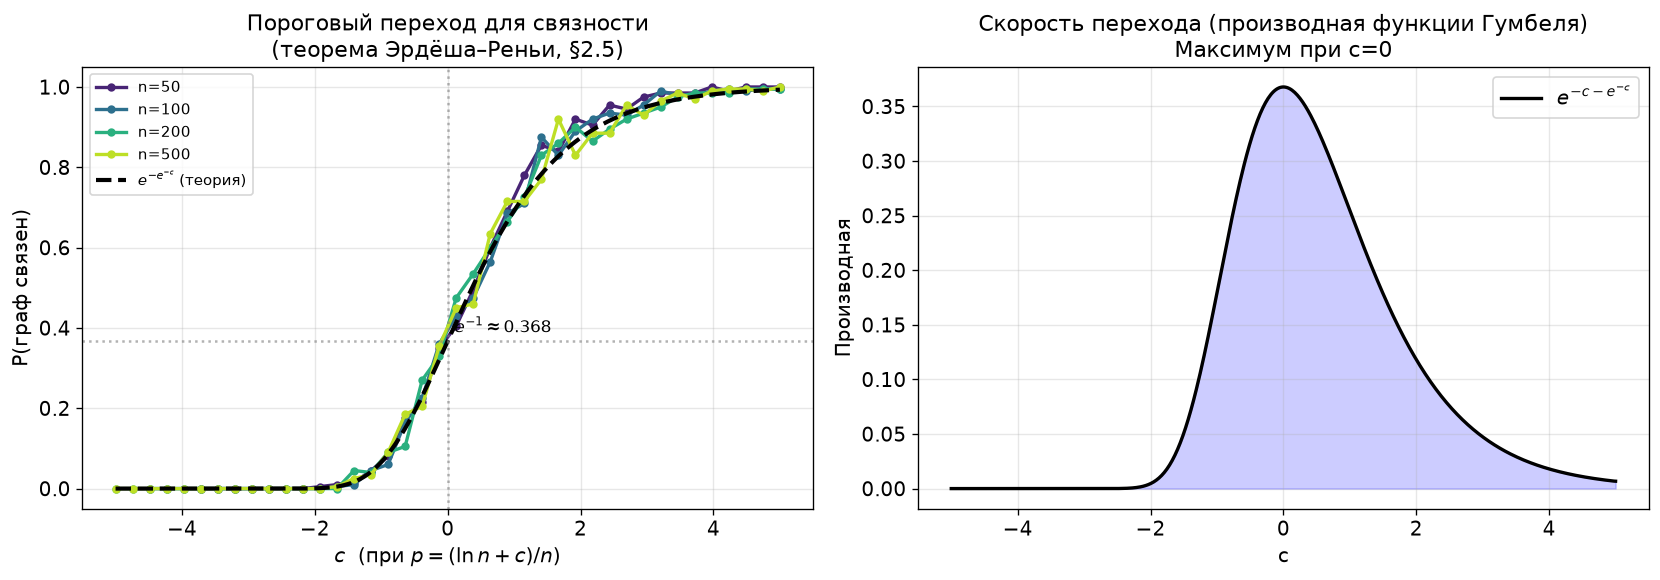

In [12]:
ns_conn = [50, 100, 200, 500]
c_vals = np.linspace(-5, 5, 40)
N_conn = 200

conn_probs = {}
for n in ns_conn:
  probs = []
  for c in c_vals:
      p = (math.log(n) + c) / n
      if not (0 < p < 1):
          probs.append(float("nan"))
          continue
      cnt = sum(nx.is_connected(nx.erdos_renyi_graph(n, p)) for _ in range(N_conn))
      probs.append(cnt / N_conn)
  conn_probs[n] = probs

c_fine = np.linspace(-5, 5, 500)
p_theor = [math.exp(-math.exp(-c)) for c in c_fine]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols3 = plt.cm.viridis(np.linspace(0.1, 0.9, len(ns_conn)))

ax = axes[0]
for n, col in zip(ns_conn, cols3):
  ax.plot(c_vals, conn_probs[n], "-o", color=col, ms=4, lw=2, label=f"n={n}")
ax.plot(c_fine, p_theor, "k--", lw=2.5, label=r"$e^{-e^{-c}}$ (теория)")
ax.axvline(0, color="gray", ls=":", alpha=0.6)
ax.axhline(math.exp(-1), color="gray", ls=":", alpha=0.6)
ax.text(0.1, math.exp(-1)+0.02, r"$e^{-1}\approx 0.368$", fontsize=10)
ax.set_xlabel(r"$c$  (при $p = (\ln n + c)/n$)")
ax.set_ylabel("P(граф связен)")
ax.set_title("Пороговый переход для связности\n(теорема Эрдёша–Реньи, §2.5)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
dp = np.gradient(p_theor, c_fine)
ax.plot(c_fine, dp, "k-", lw=2, label=r"$e^{-c-e^{-c}}$")
ax.fill_between(c_fine, dp, alpha=0.2, color="blue")
ax.set_xlabel("c")
ax.set_ylabel("Производная")
ax.set_title("Скорость перехода (производная функции Гумбеля)\nМаксимум при c=0")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Эксперимент 2. Диаметр связных графов

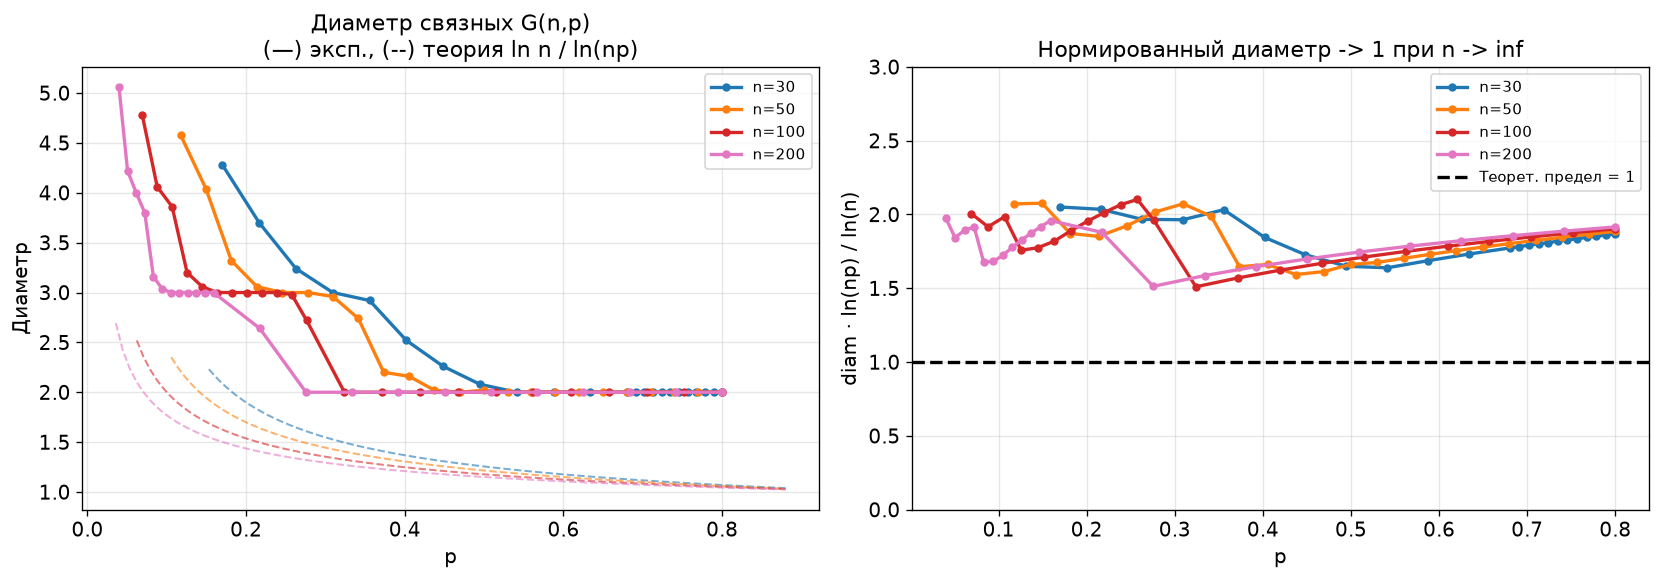

Примечание: формула diam ~ ln(n)/ln(np) — асимптотика при n -> inf.
При n=30–200 и p ≥ 0.3 граф плотный (np >> ln n),
диаметр зажат на 2. Нормировка -> ~1.7–1.9 (не 1) при конечных n.


In [13]:
ns_diam = [30, 50, 100, 200]
N_diam = 50
MAX_ATT = 20

diam_res = {}
for n in ns_diam:
  thresh = math.log(n) / n
  ps_d = np.clip(np.concatenate([
      np.linspace(thresh * 1.5, thresh * 6, 12),
      np.linspace(thresh * 6, 0.8, 12),
  ]), 0.01, 0.99)
  diam_res[n] = {}
  for p in ps_d:
      diams = []
      for _ in range(N_diam):
          for _ in range(MAX_ATT):
              G = nx.erdos_renyi_graph(n, p)
              if nx.is_connected(G):
                  diams.append(nx.diameter(G))
                  break
      diam_res[n][p] = np.mean(diams) if diams else np.nan

cols4 = plt.cm.tab10(np.linspace(0, 0.6, len(ns_diam)))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for n, col in zip(ns_diam, cols4):
  ps_used = sorted(diam_res[n].keys())
  d_vals = [diam_res[n][p] for p in ps_used]
  valid = [(p, d) for p, d in zip(ps_used, d_vals) if not np.isnan(d)]
  if not valid:
      continue
  pv, dv = zip(*valid)
  ax.plot(pv, dv, "-o", color=col, ms=4, lw=2, label=f"n={n}")
  pf = np.linspace(min(pv)*0.9, max(pv)*1.1, 100)
  ax.plot(pf, [math.log(n)/math.log(n*p) if n*p > 1 else float('nan') for p in pf], "--", color=col, alpha=0.6, lw=1.2)
ax.set_xlabel("p")
ax.set_ylabel("Диаметр")
ax.set_title("Диаметр связных G(n,p)\n(—) эксп., (--) теория ln n / ln(np)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
for n, col in zip(ns_diam, cols4):
  ps_used = sorted(diam_res[n].keys())
  normed = []
  ps_plot = []
  for p in ps_used:
      d = diam_res[n][p]
      if np.isnan(d) or n*p <= 1:
          continue
      normed.append(d * math.log(n*p) / math.log(n))
      ps_plot.append(p)
  if normed:
      ax.plot(ps_plot, normed, "-o", color=col, ms=4, lw=2, label=f"n={n}")
ax.axhline(1.0, color="black", ls="--", lw=2, label="Теорет. предел = 1")
ax.set_xlabel("p")
ax.set_ylabel(r"diam $\cdot$ ln(np) / ln(n)")
ax.set_title("Нормированный диаметр -> 1 при n -> inf")
ax.set_ylim(0, 3)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Примечание: формула diam ~ ln(n)/ln(np) — асимптотика при n -> inf.")
print("При n=30–200 и p ≥ 0.3 граф плотный (np >> ln n),")
print("диаметр зажат на 2. Нормировка -> ~1.7–1.9 (не 1) при конечных n.")

### Эксперимент 3. Диаметр при p = c/n, n = 500


Диаметр vs c при n=500, p=c/n:
  c= 2.5, p=0.0050: diam_эмп=nan, diam_теор=6.78
  c= 3.0, p=0.0060: diam_эмп=nan, diam_теор=5.66
  c= 4.0, p=0.0080: diam_эмп=nan, diam_теор=4.48
  c= 5.0, p=0.0100: diam_эмп=8.2, diam_теор=3.86
  c= 7.0, p=0.0140: diam_эмп=6.2, diam_теор=3.19
  c=10.0, p=0.0200: diam_эмп=5.0, diam_теор=2.70
  c=15.0, p=0.0300: diam_эмп=4.0, diam_теор=2.29
  c=20.0, p=0.0400: diam_эмп=4.0, diam_теор=2.07
  c=30.0, p=0.0600: diam_эмп=3.0, diam_теор=1.83
  c=50.0, p=0.1000: diam_эмп=3.0, diam_теор=1.59


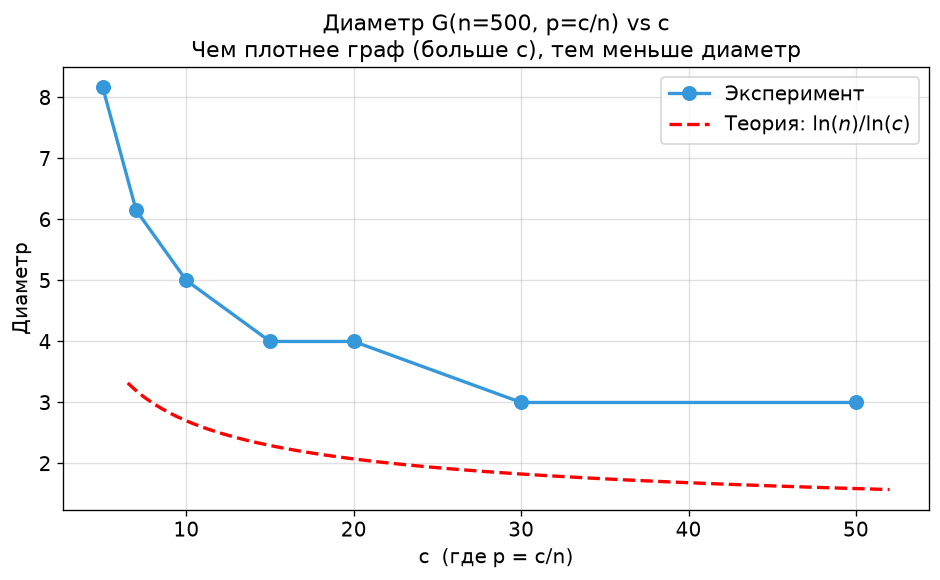


Примечание: nan при c=2.5–4.0 означает, что граф при n=500, p=c/n
почти наверное несвязен (порог связности: c > ln(n) ≈ 6.2).
Формула diam ~ ln(n)/ln(c) применима только при c > ln(n).


In [14]:
n_fixed_d = 500
cs_range = [2.5, 3, 4, 5, 7, 10, 15, 20, 30, 50]
N_diam_c = 20

diam_by_c = []
print(f"\nДиаметр vs c при n={n_fixed_d}, p=c/n:")
for c in cs_range:
  p = c / n_fixed_d
  diams = []
  tries = 0
  while len(diams) < N_diam_c and tries < 100:
      tries += 1
      G = nx.erdos_renyi_graph(n_fixed_d, p)
      if nx.is_connected(G):
          diams.append(nx.diameter(G))
  emp = np.mean(diams) if diams else float("nan")
  diam_by_c.append(emp)
  theor = math.log(n_fixed_d) / math.log(c)
  print(f"  c={c:4.1f}, p={p:.4f}: diam_эмп={emp:.1f}, diam_теор={theor:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cs_range, diam_by_c, "o-", color="#3498DB", lw=2, ms=8, label="Эксперимент")
nf_c = np.linspace(6.5, 52, 200)
ax.plot(nf_c, [math.log(n_fixed_d)/math.log(c) for c in nf_c], "r--", lw=2, label=r"Теория: $\ln(n)/\ln(c)$")
ax.set_xlabel("c  (где p = c/n)")
ax.set_ylabel("Диаметр")
ax.set_title(f"Диаметр G(n={n_fixed_d}, p=c/n) vs c\n"
             "Чем плотнее граф (больше c), тем меньше диаметр")
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


print("\nПримечание: nan при c=2.5–4.0 означает, что граф при n=500, p=c/n")
print("почти наверное несвязен (порог связности: c > ln(n) ≈ 6.2).")
print("Формула diam ~ ln(n)/ln(c) применима только при c > ln(n).")

## Выводы

### Часть 1. Алгоритм Каргера

- Нижняя граница $2/(n(n-1))$ выполняется и сильно занижена: на $G(n, 0.5)$ эмпирическая вероятность успеха выше в 5,5 раза при n = 5 и в 55,5 раза при n = 30. Граница считается для одного минимального разреза, а их обычно несколько.
- Номер первого успеха распределён геометрически с $p_{emp} = 0.213$ (n = 15). По нижней границе $p_0 = 0.0095$ для гарантии 99 % нужно 482 запуска, по $p_{emp}$ — 20.
- Вероятность успеха определяется размером разреза: при n = 20 и p = 0,1 ($\lambda \approx 1$) она 0,71, при p = 0,9 ($\lambda \approx 14$) — 0,11.
- На Dumbbell(k) с $\lambda = 1$ вероятность растёт с k, от 0,45 до 0,75, и выше, чем у $G(2k, 0.5)$ того же размера: 0,57 против 0,31 при n = 12, 0,75 против 0,14 при n = 30.

### Часть 2. Хроматическое и цикломатическое число

- Жадная раскраска выше формулы Боллобаша: при p = 0,5 в 2,74 раза для n = 20 и в 2,59 раза для n = 200, отношение медленно убывает с ростом n. От p отношение зависит сильнее: от 3,5 при малых p до 1,4 при p = 0,98.
- $E[\mu] = \binom{n}{2}p - n + 1$ совпадает с экспериментом в пределах 1,5 % при p = 0,1 и 0,5. На пороге связности $p = \ln n / n$ расхождение 5 % при n = 50 и 0,1 % при n = 500. Ниже порога формула не работает: граф несвязен, при p = 2/n она даёт 0, а $\mu = 79$ при n = 500.
- Порог циклов $p = 1/n$: при p = 0,5/n $\mu \approx 0.03$, при p = 1/n от 0,4 до 1,0, при p = 2/n от 8 до 79.

### Часть 3. Связность и диаметр

- Доля связных графов при $p = (\ln n + c)/n$ ложится на $e^{-e^{-c}}$ для всех n от 50 до 500, при c = 0 кривые проходят около $e^{-1} \approx 0.368$.
- Диаметр связных $G(n,p)$ при n ≤ 200 больше асимптотики $\ln n / \ln(np)$: нормированный диаметр держится между 1,5 и 2,1, плотные графы имеют диаметр 2.
- При n = 500 и p = c/n диаметр убывает с ростом c: 8,2 при c = 5, 5 при c = 10, 3 при c = 30 и 50. Формула $\ln n / \ln c$ повторяет убывание, но занижает значение в 1,6–2,1 раза. При c ≤ 4 связных графов за 100 попыток нет: порог связности $c = \ln 500 \approx 6.2$.